In [1]:
from helper_func import *
import helper_func as hf
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from spellchecker import SpellChecker
from textblob import TextBlob
from multiprocessing import Pool
from tqdm import tqdm
import numpy as np
import pandas as pd
# Preprocessing
from nltk.tokenize import word_tokenize, sent_tokenize
import operator
from spellchecker import SpellChecker
from tqdm import tqdm  # Import tqdm
import re
import inflect
from wordsegment import load, segment
from nltk.corpus import words
word_list = set(words.words())

2024-04-13 22:35:29.976155: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-04-13 22:35:30.016657: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-13 22:35:30.727243: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
[nltk_data] Downloading package punkt to /home/laptop/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/laptop/nltk_data...
[nltk_data]   Package averaged_perceptr

In [2]:
train = pd.read_csv('data/train.csv')

In [3]:
train.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


In [4]:
# time the run time

import time

start = time.time()

# Clean the train and test text data

train = hf.clean_text(train, col_name = 'full_text')


end = time.time()

print(f"Time taken to clean text: {end - start} seconds")

Starting text cleaning process. 

Time taken to clean text: 30.93817925453186 seconds


In [5]:
train.head()

,essay_id,full_text,score,lowered,clean_text
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live the thing...
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...",we all heard about venus the planet without al...
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...",dear state senator this is a letter to argue i...


In [6]:
train['misspelling_count'] = train['clean_text'].apply(count_misspellings)

In [7]:
train

,essay_id,full_text,score,lowered,clean_text,misspelling_count
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live the thing...,24
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,9
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,8
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...",we all heard about venus the planet without al...,7
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...",dear state senator this is a letter to argue i...,9
...,...,...,...,...,...,...
17302,ffd378d,"the story "" The Challenge of Exploing Venus "" ...",2,"the story "" the challenge of exploing venus "" ...",the story the challenge of exploing venus is a...,13
17303,ffddf1f,Technology has changed a lot of ways that we l...,4,technology has changed a lot of ways that we l...,technology has changed a lot of ways that we l...,16
17304,fff016d,If you don't like sitting around all day than ...,2,if you don't like sitting around all day than ...,if you do not like sitting around all day than...,2
17305,fffb49b,"In ""The Challenge of Exporing Venus,"" the auth...",1,"in ""the challenge of exporing venus,"" the auth...",in the challenge of exporing venus the author ...,5


In [9]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from textstat import flesch_reading_ease, gunning_fog
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
import numpy as np

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('vader_lexicon')


def count_special_characters(text):
    """
    Counts the number of special characters in the given text.

    :param text: The text to analyze for special characters.
    :return: Count of special characters.
    """
    # Regex to find non-alphanumeric and non-space characters
    special_chars = re.findall(r"[^A-Za-z0-9\s]", text)
    return len(special_chars)

def add_text_features(df, text_column,status='Pre'):
    """
    Enhances the DataFrame with multiple text-based features, including the count of special characters.

    :param df: DataFrame containing the essay texts.
    :param text_column: Column name containing text data.
    :return: DataFrame with added features.
    """
    # Tokenization, Sentence Splitting, and POS Tagging
    df[f'{status}_tokens'] = df[text_column].apply(nltk.word_tokenize)
    df[f'{status}_sentences'] = df[text_column].apply(nltk.sent_tokenize)
    df[f'{status}_pos_tags'] = df[f'{status}_tokens'].apply(nltk.pos_tag)

    # Basic counts
    df[f'{status}_word_count'] = df[f'{status}_tokens'].apply(len)
    df[f'{status}_sentence_count'] = df[f'{status}_sentences'].apply(len)
    df[f'{status}_avg_sentence_length'] = df[f'{status}_word_count'] / df[f'{status}_sentence_count']

    # Vocabulary richness
    df[f'{status}_lexical_diversity'] = df[f'{status}_tokens'].apply(lambda x: len(set(x)) / len(x) if x else 0)

    # Readability scores
    df[f'{status}_flesch_reading_ease'] = df[text_column].apply(flesch_reading_ease)
    df[f'{status}_gunning_fog_index'] = df[text_column].apply(gunning_fog)

    # Sentiment analysis
    sia = SentimentIntensityAnalyzer()

    df[f'{status}_sentiment_score'] = df[text_column].apply(lambda x: sia.polarity_scores(x)['compound'])

    # Advanced vocabulary usage
    
    english_stopwords = set(stopwords.words('english'))

    df[f'{status}_advanced_vocab_usage'] = df[f'{status}_tokens'].apply(lambda x: len([word for word in x if word.lower() not in english_stopwords and len(word) > 6]))

    # Grammatical errors (Placeholder for actual grammar check logic)
    df[f'{status}_grammar_errors'] = np.random.randint(0, 3, size=len(df))  # Random errors count as a placeholder

    # Special characters count
    df[f'{status}_special_characters_count'] = df[text_column].apply(count_special_characters)

    return df

[nltk_data] Downloading package punkt to /home/laptop/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/laptop/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/laptop/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/laptop/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [10]:
# Adding text features
train = add_text_features(train, 'full_text', status= 'Pre')

In [11]:
train

,essay_id,full_text,score,lowered,clean_text,misspelling_count,Pre_tokens,Pre_sentences,Pre_pos_tags,Pre_word_count,Pre_sentence_count,Pre_avg_sentence_length,Pre_lexical_diversity,Pre_flesch_reading_ease,Pre_gunning_fog_index,Pre_sentiment_score,Pre_advanced_vocab_usage,Pre_grammar_errors,Pre_special_characters_count
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live the thing...,24,"[Many, people, have, car, where, they, live, ....","[Many people have car where they live., The th...","[(Many, JJ), (people, NNS), (have, VBP), (car,...",545,13,41.923077,0.455046,57.98,17.33,0.9937,66,2,41
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,9,"[I, am, a, scientist, at, NASA, that, is, disc...",[I am a scientist at NASA that is discussing t...,"[(I, PRP), (am, VBP), (a, DT), (scientist, NN)...",371,21,17.666667,0.452830,87.55,7.48,0.7705,38,1,41
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,8,"[People, always, wish, they, had, the, same, t...",[People always wish they had the same technolo...,"[(People, NNS), (always, RB), (wish, VBP), (th...",605,24,25.208333,0.401653,65.15,11.49,-0.9731,94,1,56
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...",we all heard about venus the planet without al...,7,"[We, all, heard, about, Venus, ,, the, planet,...","[We all heard about Venus, the planet without ...","[(We, PRP), (all, DT), (heard, VBP), (about, I...",511,20,25.550000,0.471624,58.32,11.91,0.9702,116,2,64
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...",dear state senator this is a letter to argue i...,9,"[Dear, ,, State, Senator, This, is, a, letter,...","[Dear, State Senator\n\nThis is a letter to ar...","[(Dear, NNP), (,, ,), (State, NNP), (Senator, ...",418,15,27.866667,0.373206,54.66,12.64,0.9771,104,0,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17302,ffd378d,"the story "" The Challenge of Exploing Venus "" ...",2,"the story "" the challenge of exploing venus "" ...",the story the challenge of exploing venus is a...,13,"[the, story, ``, The, Challenge, of, Exploing,...","[the story "" The Challenge of Exploing Venus ""...","[(the, DT), (story, NN), (``, ``), (The, DT), ...",167,9,18.555556,0.580838,70.94,9.72,0.3626,24,0,12
17303,ffddf1f,Technology has changed a lot of ways that we l...,4,technology has changed a lot of ways that we l...,technology has changed a lot of ways that we l...,16,"[Technology, has, changed, a, lot, of, ways, t...",[Technology has changed a lot of ways that we ...,"[(Technology, NN), (has, VBZ), (changed, VBN),...",644,26,24.769231,0.406832,56.39,11.42,0.9973,131,2,68
17304,fff016d,If you don't like sitting around all day than ...,2,if you don't like sitting around all day than ...,if you do not like sitting around all day than...,2,"[If, you, do, n't, like, sitting, around, all,...",[If you don't like sitting around all day than...,"[(If, IN), (you, PRP), (do, VBP), (n't, RB), (...",235,15,15.666667,0.485106,90.80,6.28,0.9803,23,1,20
17305,fffb49b,"In ""The Challenge of Exporing Venus,"" the auth...",1,"in ""the challenge of exporing venus,"" the auth...",in the challenge of exporing venus the author ...,5,"[In, ``, The, Challenge, of, Exporing, Venus, ...","[In ""The Challenge of Exporing Venus,"" the aut...","[(In, IN), (``, ``), (The, DT), (Challenge, NN...",264,11,24.000000,0.541667,58.72,11.66,0.9513,66,0,37


In [12]:
text_col = 'clean_text'   # 'segmented_text'


glove_path = '/home/laptop/github/kaggle/scoring/data/glove-840B-300d.txt'
paragran_path = '/home/laptop/github/kaggle/scoring/data/paragram-300-sl999.txt'
fastetxt_path = '/home/laptop/github/kaggle/scoring/data/wiki-news-1M-300d.vec'


# Rebuild and check vocab after cleaning contractions

train, glove, paragram, fastetxt = embedding_checks(train, glove_path, paragran_path, fastetxt_path, col_name= text_col)

Loading embeddings from /home/laptop/github/kaggle/scoring/data/paragram-300-sl999.txtLoading embeddings from /home/laptop/github/kaggle/scoring/data/wiki-news-1M-300d.vecLoading embeddings from /home/laptop/github/kaggle/scoring/data/glove-840B-300d.txt




Reading Embedding File: 999995it [00:31, 32171.85it/s]


Loaded embeddings from /home/laptop/github/kaggle/scoring/data/wiki-news-1M-300d.vec


Reading Embedding File: 1703756it [00:59, 28653.31it/s]


Loaded embeddings from /home/laptop/github/kaggle/scoring/data/paragram-300-sl999.txt


...

Coverage checked.
Checking coverage.


Checking Words: 100%|██████████| 65918/65918 [00:00<00:00, 1279615.54it/s]


Coverage checked.
Checking coverage.


Checking Words: 100%|██████████| 65918/65918 [00:00<00:00, 1605790.15it/s]


Coverage checked.
Processed dataset.


In [13]:
misspellings = []

oov = glove + paragram + fastetxt

for word, _ in oov:

    misspellings.append(word)

    misspellings = list(set(misspellings))

print(f"Number of misspelled words: {len(misspellings)}")

# print(f"Misspelled words: {misspellings}")

Number of misspelled words: 36335


In [14]:
# Example usage
corrected_words, uncorrected_words = main(misspellings)

  0%|          | 0/21 [00:00<?, ?it/s]

In [15]:
# Assuming df is your DataFrame and 'clean_text' is the column you want to correct

correction_dict = dict(corrected_words)

train['corrected_text'] = train[text_col].apply(lambda x: apply_corrections_to_text(x, correction_dict))


In [16]:
print(f"Corrected words: {len(corrected_words)}")
print(f"Uncorrected words: {len(uncorrected_words)}")

Corrected words: 31994
Uncorrected words: 4341


In [17]:
# Apply the parallelization

train = parallelize_dataframe(train, apply_segmentation)

train.head()

100%|██████████| 20/20 [00:09<00:00,  2.08it/s]


,essay_id,full_text,score,lowered,clean_text,misspelling_count,Pre_tokens,Pre_sentences,Pre_pos_tags,Pre_word_count,...,Pre_avg_sentence_length,Pre_lexical_diversity,Pre_flesch_reading_ease,Pre_gunning_fog_index,Pre_sentiment_score,Pre_advanced_vocab_usage,Pre_grammar_errors,Pre_special_characters_count,corrected_text,segmented_text
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live the thing...,24,"[Many, people, have, car, where, they, live, ....","[Many people have car where they live., The th...","[(Many, JJ), (people, NNS), (have, VBP), (car,...",545,...,41.923077,0.455046,57.98,17.33,0.9937,66,2,41,many people have car where they live the thing...,many people have car where they live the thing...
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,9,"[I, am, a, scientist, at, NASA, that, is, disc...",[I am a scientist at NASA that is discussing t...,"[(I, PRP), (am, VBP), (a, DT), (scientist, NN)...",371,...,17.666667,0.452830,87.55,7.48,0.7705,38,1,41,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,8,"[People, always, wish, they, had, the, same, t...",[People always wish they had the same technolo...,"[(People, NNS), (always, RB), (wish, VBP), (th...",605,...,25.208333,0.401653,65.15,11.49,-0.9731,94,1,56,people always wish they had the same technolog...,people always wish they had the same technolog...
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...",we all heard about venus the planet without al...,7,"[We, all, heard, about, Venus, ,, the, planet,...","[We all heard about Venus, the planet without ...","[(We, PRP), (all, DT), (heard, VBP), (about, I...",511,...,25.550000,0.471624,58.32,11.91,0.9702,116,2,64,we all heard about venus the planet without al...,we all heard about venus the planet without al...
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...",dear state senator this is a letter to argue i...,9,"[Dear, ,, State, Senator, This, is, a, letter,...","[Dear, State Senator\n\nThis is a letter to ar...","[(Dear, NNP), (,, ,), (State, NNP), (Senator, ...",418,...,27.866667,0.373206,54.66,12.64,0.9771,104,0,47,dear state senator this is a letter to argue i...,dear state senator this is a letter to argue i...


In [18]:
text_col = 'segmented_text'  


glove_path = '/home/laptop/github/kaggle/scoring/data/glove-840B-300d.txt'
paragran_path = '/home/laptop/github/kaggle/scoring/data/paragram-300-sl999.txt'
fastetxt_path = '/home/laptop/github/kaggle/scoring/data/wiki-news-1M-300d.vec'


# Rebuild and check vocab after cleaning contractions

train, glove, paragram, fastetxt = embedding_checks(train, glove_path, paragran_path, fastetxt_path, col_name= text_col)


misspellings = []

oov = glove + paragram + fastetxt

for word, _ in oov:

    misspellings.append(word)

    misspellings = list(set(misspellings))

print(f"Number of misspelled words: {len(misspellings)}")

# print(f"Misspelled words: {misspellings}")


# Example usage
corrected_words, uncorrected_words = main(misspellings)

# Assuming df is your DataFrame and 'clean_text' is the column you want to correct

correction_dict = dict(corrected_words)

train['corrected_text'] = train[text_col].apply(lambda x: apply_corrections_to_text(x, correction_dict))

print(f"Corrected words: {len(corrected_words)}")
print(f"Uncorrected words: {len(uncorrected_words)}")


Loading embeddings from /home/laptop/github/kaggle/scoring/data/glove-840B-300d.txtLoading embeddings from /home/laptop/github/kaggle/scoring/data/wiki-news-1M-300d.vecLoading embeddings from /home/laptop/github/kaggle/scoring/data/paragram-300-sl999.txt




Reading Embedding File: 999995it [00:29, 34248.49it/s]]


Loaded embeddings from /home/laptop/github/kaggle/scoring/data/wiki-news-1M-300d.vec


Reading Embedding File: 2196017it [01:01, 35950.22it/s]


Loaded embeddings from /home/laptop/github/kaggle/scoring/data/glove-840B-300d.txt


...

Coverage checked.
Checking coverage.


Checking Words: 100%|██████████| 25174/25174 [00:00<00:00, 1726695.16it/s]


Coverage checked.
Processed dataset.
Number of misspelled words: 1336


  0%|          | 0/21 [00:00<?, ?it/s]

Corrected words: 1259
Uncorrected words: 77


In [19]:
train = add_text_features(train, 'corrected_text', status='Post')
train.head()

,essay_id,full_text,score,lowered,clean_text,misspelling_count,Pre_tokens,Pre_sentences,Pre_pos_tags,Pre_word_count,...,Post_word_count,Post_sentence_count,Post_avg_sentence_length,Post_lexical_diversity,Post_flesch_reading_ease,Post_gunning_fog_index,Post_sentiment_score,Post_advanced_vocab_usage,Post_grammar_errors,Post_special_characters_count
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live. the thin...,many people have car where they live the thing...,24,"[Many, people, have, car, where, they, live, ....","[Many people have car where they live., The th...","[(Many, JJ), (people, NNS), (have, VBP), (car,...",545,...,554,1,554.0,0.451264,-457.00,223.19,0.9759,60,0,0
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,i am a scientist at nasa that is discussing th...,9,"[I, am, a, scientist, at, NASA, that, is, disc...",[I am a scientist at NASA that is discussing t...,"[(I, PRP), (am, VBP), (a, DT), (scientist, NN)...",371,...,339,1,339.0,0.430678,-238.78,136.07,0.7050,35,0,0
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,people always wish they had the same technolog...,8,"[People, always, wish, they, had, the, same, t...",[People always wish they had the same technolo...,"[(People, NNS), (always, RB), (wish, VBP), (th...",605,...,561,1,561.0,0.418895,-481.03,226.47,-0.7712,90,0,0
3,001bdc0,"We all heard about Venus, the planet without a...",4,"we all heard about venus, the planet without a...",we all heard about venus the planet without al...,7,"[We, all, heard, about, Venus, ,, the, planet,...","[We all heard about Venus, the planet without ...","[(We, PRP), (all, DT), (heard, VBP), (about, I...",511,...,467,1,467.0,0.475375,-393.06,189.58,0.9531,116,1,0
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,"dear, state senator\n\nthis is a letter to arg...",dear state senator this is a letter to argue i...,9,"[Dear, ,, State, Senator, This, is, a, letter,...","[Dear, State Senator\n\nThis is a letter to ar...","[(Dear, NNP), (,, ,), (State, NNP), (Senator, ...",418,...,397,1,397.0,0.367758,-314.57,160.82,0.9894,98,2,0


In [20]:
train_essays, validation_essays = custom_train_validation_split(train, test_size=0.25, random_state=42)

In [21]:
train_essays, _ = preprocess_data(train_essays)

Preprocessing Data.......
Generating Text Based Features.......


In [22]:
validation_essays, _ = preprocess_data(validation_essays) #, tfidf_vectorizer=tfidf_vectorizer)

Preprocessing Data.......
Generating Text Based Features.......


In [24]:
train_essays.to_parquet('train_essays.parquet')
validation_essays.to_parquet('validation_essays.parquet')

In [23]:
train_essays.columns

Index(['essay_id', 'full_text', 'score', 'lowered', 'clean_text',
       'misspelling_count', 'Pre_tokens', 'Pre_sentences', 'Pre_pos_tags',
       'Pre_word_count', 'Pre_sentence_count', 'Pre_avg_sentence_length',
       'Pre_lexical_diversity', 'Pre_flesch_reading_ease',
       'Pre_gunning_fog_index', 'Pre_sentiment_score',
       'Pre_advanced_vocab_usage', 'Pre_grammar_errors',
       'Pre_special_characters_count', 'corrected_text', 'segmented_text',
       'Post_tokens', 'Post_sentences', 'Post_pos_tags', 'Post_word_count',
       'Post_sentence_count', 'Post_avg_sentence_length',
       'Post_lexical_diversity', 'Post_flesch_reading_ease',
       'Post_gunning_fog_index', 'Post_sentiment_score',
       'Post_advanced_vocab_usage', 'Post_grammar_errors',
       'Post_special_characters_count', 'word_count', 'sentence_count',
       'len_text', 'stop_count', 'noun_count', 'ne_count', 'avg_word_len',
       'lex_div', 'polarity', 'subjectivity', 'flesch_score'],
      dtype='objec

In [25]:
drop_cols = ['full_text', 'lowered', 'clean_text',
       'misspelling_count', 'Pre_tokens', 'Pre_sentences'
       , 'Pre_pos_tags','corrected_text', 'segmented_text',
       'Post_tokens', 'Post_sentences', 'Post_pos_tags']

train_df = train_essays.copy()
val_df = validation_essays.copy()

train_df.drop(columns=drop_cols, inplace= True)
val_df.drop(columns=drop_cols, inplace= True)



In [26]:
train_df.head()

,essay_id,score,Pre_word_count,Pre_sentence_count,Pre_avg_sentence_length,Pre_lexical_diversity,Pre_flesch_reading_ease,Pre_gunning_fog_index,Pre_sentiment_score,Pre_advanced_vocab_usage,...,sentence_count,len_text,stop_count,noun_count,ne_count,avg_word_len,lex_div,polarity,subjectivity,flesch_score
1,000fe60,3,371,21,17.666667,0.452830,87.55,7.48,0.7705,38,...,1,1634,201,68,0,3.823009,0.430678,0.101786,0.444643,-238.78
2,001ab80,4,605,24,25.208333,0.401653,65.15,11.49,-0.9731,94,...,1,3020,277,130,0,4.385027,0.418895,0.171804,0.458290,-481.03
4,002ba53,3,418,15,27.866667,0.373206,54.66,12.64,0.9771,104,...,1,2187,202,107,0,4.511335,0.367758,0.179018,0.564807,-314.57
6,0033037,2,195,7,27.857143,0.538462,62.61,13.08,0.1245,45,...,1,1033,105,57,0,4.201005,0.512563,0.014286,0.437500,-104.12
7,0033bf4,3,401,26,15.423077,0.384040,83.15,6.20,0.9962,54,...,1,1923,178,68,0,4.374302,0.377095,0.245500,0.439167,-266.52


In [27]:
feature_cols = []

for col in train_df.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col) 

In [28]:
from sklearn.preprocessing import StandardScaler

train_labels = train_df['score']

val_labels = val_df['score']

train_features = train_df[feature_cols]

val_features = val_df[feature_cols]

scaler = StandardScaler()

train_feats_scaled = scaler.fit_transform(train_features)

val_feats_scaled = scaler.transform(val_features)


import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [29]:
import tensorflow as tf

# Assuming train_labels and val_labels are your label arrays with classes 1-6

train_labels_one_hot = tf.keras.utils.to_categorical(train_labels - 1, num_classes=6)
val_labels_one_hot = tf.keras.utils.to_categorical(val_labels - 1, num_classes=6)


In [30]:
import tensorflow as tf

train_class = tf.data.Dataset.from_tensor_slices((train_feats_scaled, 
                                                train_labels_one_hot)).shuffle(len(train_features)).batch(32)

val_class = tf.data.Dataset.from_tensor_slices((val_feats_scaled, 
                                              val_labels_one_hot)).batch(32)


In [31]:
train_labels.shape

(12980,)

In [32]:
val_labels.shape

(4327,)

In [33]:
import tensorflow as tf
import numpy as np

def quadratic_weighted_kappa(y_true, y_pred):
    """
    Calculates the Quadratic Weighted Kappa (QWK) aka Cohen's Kappa with quadratic weights.
    
    Parameters:
    y_true (tensor): The ground truth labels as one-hot encoded vectors.
    y_pred (tensor): The predicted probability distributions.
    
    Returns:
    float: The QWK score.
    """
    # Convert predictions to class indices
    y_pred_classes = tf.argmax(y_pred, axis=-1)
    y_pred_one_hot = tf.one_hot(y_pred_classes, depth=y_true.shape[-1])

    # Calculate the confusion matrix
    confusion_matrix = tf.math.confusion_matrix(tf.argmax(y_true, axis=1), y_pred_classes, num_classes=y_true.shape[-1])

    # Normalize the confusion matrix
    confusion_matrix = tf.cast(confusion_matrix, dtype=tf.float32)
    confusion_matrix = confusion_matrix / tf.reduce_sum(confusion_matrix)

    # Calculate weights
    num_classes = tf.shape(confusion_matrix)[0]
    weights = tf.cast(tf.range(num_classes), dtype=tf.float32) / tf.cast(num_classes - 1, dtype=tf.float32)
    weights = tf.square(tf.expand_dims(weights, -1) - tf.expand_dims(weights, 0))

    # Calculate the observed and expected agreement
    observed = tf.reduce_sum(weights * confusion_matrix)
    expected = tf.reduce_sum(
        weights * tf.matmul(
            tf.reshape(tf.reduce_sum(confusion_matrix, axis=1), [-1, 1]),
            tf.reshape(tf.reduce_sum(confusion_matrix, axis=0), [1, -1])
        )
    )

    # Calculate the kappa score
    kappa = 1.0 - observed / expected
    return kappa


In [34]:
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import schedules, AdamW, RMSprop

def build_classification_model(hp, input_shape=(train_feats_scaled.shape[1],)):
    
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)  # number of hidden layers
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)  # neurons in each hidden layer
    l2_reg = hp.Float("l2_reg", min_value=1e-6, max_value=1e-2, sampling="log")  # L2 regularization
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")  # learning rate

    optimizer_choice = hp.Choice("optimizer_choice", ['adam', 'sgd', 'RMSprop', 'Adagrad', 'Adadelta', 'Nadam', 'Ftrl', 'L-BFGS'])

    # Learning rate schedulers
    lr_schedule = schedules.ExponentialDecay(initial_learning_rate=learning_rate,
                                             decay_steps=10000,
                                             decay_rate=0.9)

    if optimizer_choice == 'adam':
        optimizer = AdamW(learning_rate=lr_schedule)
    elif optimizer_choice == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
    elif optimizer_choice == 'RMSprop':
        optimizer = RMSprop(learning_rate=lr_schedule)
    elif optimizer_choice == 'Adagrad':
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=lr_schedule)
    elif optimizer_choice == 'Adadelta':
        optimizer = tf.keras.optimizers.Adadelta(learning_rate=lr_schedule)
    elif optimizer_choice == 'Nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=lr_schedule)
    else:
        optimizer = tf.keras.optimizers.Ftrl(learning_rate=lr_schedule)

    model = tf.keras.models.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=input_shape))  # Explicit input layer

    model.add(tf.keras.layers.Dense(n_neurons, 
                                    activation='relu', 
                                    kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))

    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.05)  # dropout rate

    # Hidden layers with Batch Normalization and Dropout
    for _ in range(n_hidden):
        model.add(tf.keras.layers.BatchNormalization())
        
        model.add(tf.keras.layers.Dense(n_neurons, 
                                        activation='relu', 
                                        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        
        model.add(tf.keras.layers.Dropout(rate=dropout_rate))

    # Output layer for 6 classes
    model.add(tf.keras.layers.Dense(6, activation='softmax'))
    
    
    
#     from tensorflow.keras.metrics import AUC

#     # For binary classification
#     roc_auc = AUC(curve='ROC')

#     # For multi-class classification (assuming one-vs-all approach)
#     roc_auc_multi = AUC(curve='ROC', multi_label=True, num_labels=6)




    # Then, you can add it to your model's compile method as a metric
    model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=[ 
                       tf.keras.metrics.CategoricalAccuracy(),
                       tf.keras.metrics.F1Score( average='weighted'),
                       tf.keras.metrics.AUC(curve='ROC', multi_label=True, num_labels=6),
                       quadratic_weighted_kappa])


    # Learning rate reduction callback
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

    return model


In [35]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import keras_tuner as kt

model_checkpoint = ModelCheckpoint('best_standard_model_epoch.keras', 
                                   save_best_only=True, monitor='val_loss', mode='min')

early_stopping = EarlyStopping(monitor='val_loss', patience=5, 
                               restore_best_weights=True)

call_backs = [model_checkpoint, early_stopping]

tuner = kt.BayesianOptimization(
    build_classification_model,
    objective='val_loss',
    max_trials=8,
    num_initial_points= 2,
    seed=1,
    overwrite=True,
    directory='tuner_2',
    project_name='standard',
)

tuner.search(train_class, epochs=1000, 
             validation_data= val_class, callbacks = call_backs, verbose=2)

best_standard_model = tuner.get_best_models(num_models=1)[0]


best_standard_model.save('best_standard_model.keras')

Trial 8 Complete [00h 00m 11s]
val_loss: 0.957396924495697

Best val_loss So Far: 0.957396924495697
Total elapsed time: 00h 17m 37s


In [36]:
# Evaluate the model on the validation dataset

results = best_standard_model.evaluate(val_class, verbose=0)

# Print all results

print(results)

[0.957396924495697, 0.8760457038879395, 0.5807719230651855, 0.5651808977127075, 0.689058780670166]


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step


2024-04-14 00:01:26.124203: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


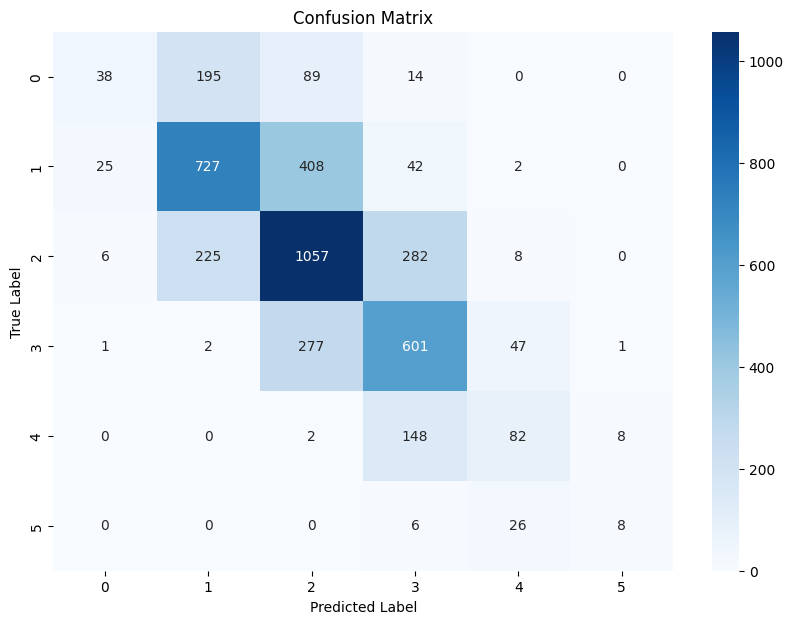

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming val_reg is your validation dataset
# Extract true labels and convert from one-hot encoding to integer labels if necessary
y_true = np.concatenate([y for x, y in val_class], axis=0)

if y_true.ndim > 1 and y_true.shape[1] > 1:  # Check if y_true is one-hot encoded
    y_true = np.argmax(y_true, axis=1)

# Predict the classes with the best model on the validation data

y_pred = best_standard_model.predict(val_feats_scaled)

y_pred_classes = np.argmax(y_pred, axis=1)  # Convert from probabilities to class labels

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# As a regression Task

In [38]:
from sklearn.preprocessing import StandardScaler
import pickle
import numpy as np

# Initialize the scaler
target_scaler = StandardScaler()

# Reshape the 1D arrays to 2D arrays with one column each
train_labels_reshaped = np.array(train_labels).reshape(-1, 1)
val_labels_reshaped = np.array(val_labels).reshape(-1, 1)

# Scale the training and validation target variables
train_target_scaled = target_scaler.fit_transform(train_labels_reshaped)
val_target_scaled = target_scaler.transform(val_labels_reshaped)

# Save the scaler object for future use
with open('target_scaler.pkl', 'wb') as f:
    pickle.dump(target_scaler, f)


In [39]:
scaler_path = 'scaler.pkl'

# Check if the file has been written correctly and is not empty
import os

if os.path.getsize(scaler_path) > 0:
    print(f"Scaler saved successfully in {scaler_path}.")
else:
    print(f"Failed to save scaler to {scaler_path}. File is empty.")

Scaler saved successfully in scaler.pkl.


In [40]:
import tensorflow as tf

train_reg = tf.data.Dataset.from_tensor_slices((train_feats_scaled, 
                                                train_target_scaled)).shuffle(len(train_feats_scaled)).batch(32)

val_reg = tf.data.Dataset.from_tensor_slices((val_feats_scaled, 
                                              val_target_scaled)).batch(32)


In [41]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import schedules, AdamW, RMSprop

def build_regression_model(hp, input_shape=(train_feats_scaled.shape[1],)):
    
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)  # number of hidden layers
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)  # neurons in each hidden layer
    l2_reg = hp.Float("l2_reg", min_value=1e-6, max_value=1e-2, sampling="log")  # L2 regularization
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")  # learning rate
    
    optimizer_choice = hp.Choice("optimizer_choice", ['adam', 'sgd', 'RMSprop', 'Adagrad', 'Adadelta', 'Nadam', 'Ftrl', 'L-BFGS'])
    
    # Learning rate schedulers
    lr_schedule = schedules.ExponentialDecay(initial_learning_rate=learning_rate,
                                             decay_steps=10000,
                                             decay_rate=0.9)
    
    if optimizer_choice == 'adam':
        optimizer = AdamW(learning_rate=lr_schedule)
    elif optimizer_choice == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule)
    elif optimizer_choice == 'RMSprop':
        optimizer = RMSprop(learning_rate=lr_schedule)
    elif optimizer_choice == 'Adagrad':
        optimizer = tf.keras.optimizers.Adagrad(learning_rate=lr_schedule)
    elif optimizer_choice == 'Adadelta':
        optimizer = tf.keras.optimizers.Adadelta(learning_rate=lr_schedule)
    elif optimizer_choice == 'Nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=lr_schedule)
    else:
        # Ftrl will be the default optimizer
        optimizer = tf.keras.optimizers.Ftrl(learning_rate=lr_schedule)

    
    model = tf.keras.models.Sequential()
    
    model.add(tf.keras.Input(shape=input_shape))  # Explicit input layer

    model.add(tf.keras.layers.Dense(hp.Int('input_units', min_value=32, max_value=512, step=32), 
                                    activation='relu'))
    
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.05)  # dropout rate
    
    # Adding Batch Normalization and dropout for each hidden layer
    for _ in range(n_hidden):
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dense(n_neurons, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        model.add(tf.keras.layers.Dropout(rate=dropout_rate))
    
    model.add(tf.keras.layers.Dense(1))  # Output layer
    
        # Then, you can add it to your model's compile method as a metric
    model.compile(optimizer=optimizer,  # Use the dynamic optimizer
              loss=tf.keras.losses.Huber(),
              metrics=['mse', 'mae'])



    # Learning rate reduction callback
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

    return model

In [42]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import keras_tuner as kt

model_checkpoint = ModelCheckpoint('best_regression_model_epoch.keras', 
                                   save_best_only=True, monitor='val_loss', mode='min')

early_stopping = EarlyStopping(monitor='val_loss', patience=5, 
                               restore_best_weights=True)

call_backs = [model_checkpoint, early_stopping]


reg_tuner = kt.BayesianOptimization(
    build_regression_model,
    objective='val_loss',
    max_trials=10,
    num_initial_points= 4,
    seed=1,
    overwrite=True,
    directory='tuner_reg',
    project_name='regresion',
)


# hyperband model 

# reg_tuner = kt.Hyperband(
#     build_regression_model,
#     objective='val_loss',
#     max_epochs=1000,
#     factor=3,
#     seed=1,
#     overwrite=True,
#     directory='tuner_reg',
#     project_name='regresion',
    
# )



reg_tuner.search(train_reg, epochs=1000, 
             validation_data= val_reg, callbacks = call_backs, verbose=2)

best_regression_model = reg_tuner.get_best_models(num_models=1)[0]


best_regression_model.save('best_regression_model.keras')

Trial 10 Complete [00h 00m 13s]
val_loss: 0.20112907886505127

Best val_loss So Far: 0.20112907886505127
Total elapsed time: 00h 17m 16s


In [43]:
reg_results = best_regression_model.evaluate(val_reg)


print(reg_results)

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - loss: 0.2042 - mae: 0.4981 - mse: 0.4333
[0.20112907886505127, 0.49766236543655396, 0.4234004020690918]


In [57]:
scaled_predictions = best_regression_model.predict(val_feats_scaled)

unscaled_predictions = target_scaler.inverse_transform(scaled_predictions)

rounded_predictions = np.round(unscaled_predictions).flatten()  # Round to nearest integer and flatten if necessary
clipped_predictions = np.clip(rounded_predictions, 1, 6) # Clip to ensure within 1-6 range
clipped_predictions = clipped_predictions.astype(int)

# Now, `clipped_predictions` contains the integer score predictions


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step


In [58]:
clipped_predictions

array([3, 4, 4, ..., 3, 2, 2])

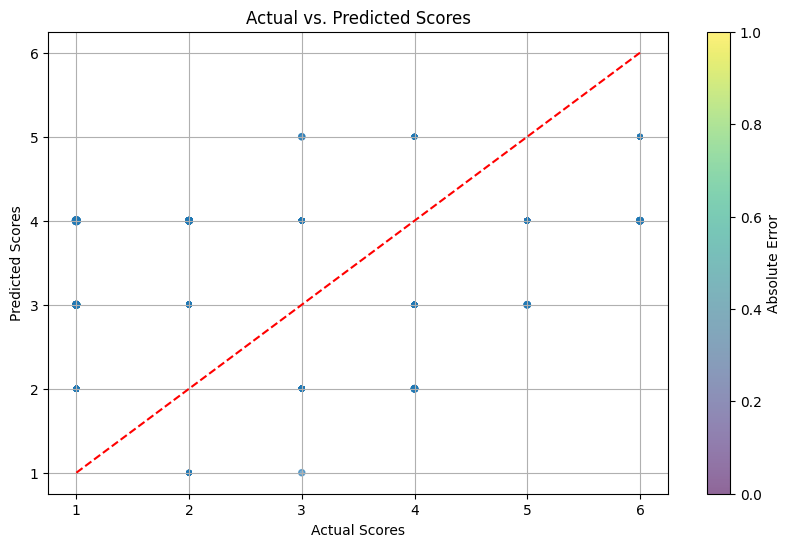

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `clipped_predictions` are your model predictions
# and `actual_scores` (or `val_labels`) are the ground truth scores for the test set

# Calculate the absolute errors
errors = np.abs(clipped_predictions - val_labels)

# You can scale the errors to ensure the sizes are visible and meaningful on the plot
# Adjust the scaling factor as needed to get a clear visual representation
size = errors * 10  # Example scaling factor

# Scatter plot of actual vs. predicted scores
plt.figure(figsize=(10, 6))
plt.scatter(val_labels, clipped_predictions, s=size, alpha=0.6)  # Use size for marker size
plt.title('Actual vs. Predicted Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.plot([1, 6], [1, 6], 'r--')  # Diagonal line representing perfect predictions
plt.colorbar(label='Absolute Error')  # Optionally add a colorbar to indicate the size meaning
plt.grid(True)
plt.show()


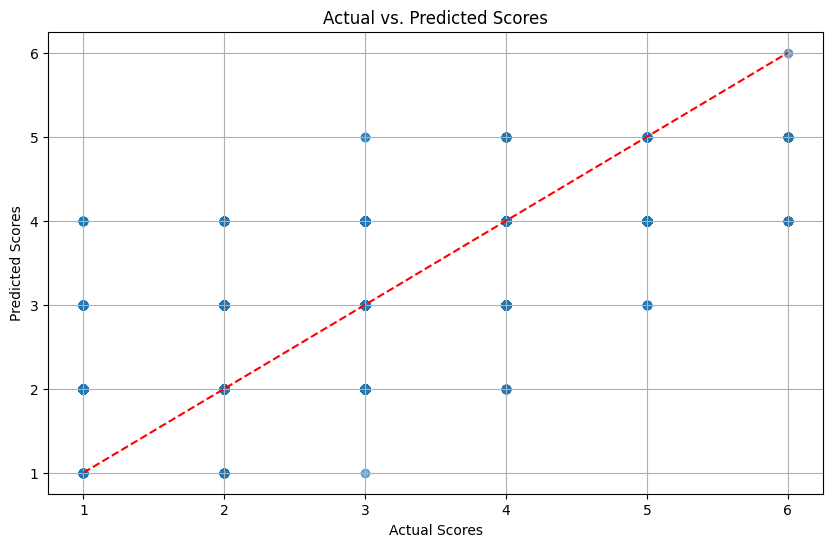

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `clipped_predictions` are your model predictions
# and `actual_scores` are the ground truth scores for the test set

# Scatter plot of actual vs. predicted scores
plt.figure(figsize=(10, 6))
plt.scatter(val_labels, clipped_predictions, alpha=0.6)
plt.title('Actual vs. Predicted Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.plot([1, 6], [1, 6], 'r--')  # Diagonal line representing perfect predictions
plt.grid(True)
plt.show()


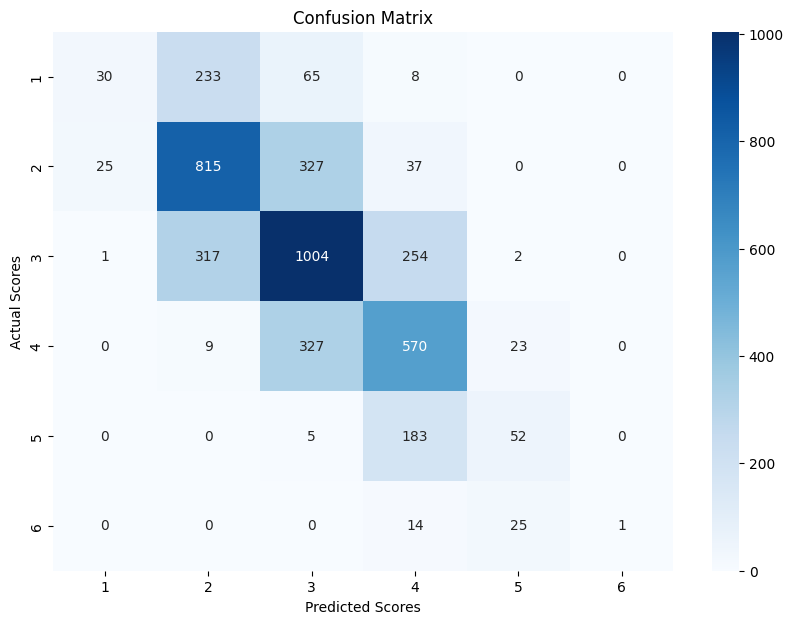

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming `clipped_predictions` contains the regression model's predictions rounded and clipped to 1-6
# And `actual_scores` contains the true scores

# Compute the confusion matrix
cm = confusion_matrix(val_labels, clipped_predictions)

# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(1, 7), yticklabels=range(1, 7))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Scores')
plt.ylabel('Actual Scores')
plt.show()


In [64]:
print(sorted(val_labels.unique()))
print(sorted(pd.Series(clipped_predictions).unique()))
print(sorted(pd.Series(y_pred_classes+1).unique()))

[1, 2, 3, 4, 5, 6]
[1, 2, 3, 4, 5, 6]
[1, 2, 3, 4, 5, 6]


In [63]:
# Example usage

actuals = val_labels
predictions = clipped_predictions


from sklearn.metrics import cohen_kappa_score

# Calculate the Quadratic Weighted Kappa
qwk_score = cohen_kappa_score(actuals, predictions, weights='quadratic')

print("Quadratic Weighted Kappa score:", qwk_score)


Quadratic Weighted Kappa score: 0.7044813767616087


In [65]:
preds = best_standard_model.predict(val_feats_scaled)
preds = np.argmax(preds, axis=1)  # Convert from probabilities to class labels

actuals = val_labels 
predictions = y_pred_classes + 1 

# Calculate the Quadratic Weighted Kappa
qwk_score = cohen_kappa_score(actuals, predictions, weights='quadratic')

print("Quadratic Weighted Kappa score:", qwk_score)


136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step
Quadratic Weighted Kappa score: 0.7037371691804692
